In [8]:
import math
import random
import numpy as np
import simpy
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')

In [9]:
LAMBDA = 10.0
MU = 3.0
SIM_TIME = 1000.0

QUEUE_CAPACITY = 30

MIN_AGENTS = 1
MAX_AGENTS = 5

ALPHA_ON = 1.0
BETA_OFF = 0.5

INITIAL_ACTIVE_AGENTS = 3

NUM_NODES = 3
ROUTING = np.array([
    [0.0, 0.35, 0.20],
    [0.15, 0.0, 0.25],
    [0.10, 0.20, 0.0],
], dtype=float)

SINGLE_NODE_ROUTING = np.array([[0.0]], dtype=float)

In [ ]:
class ServiceNode:
    def __init__(
        self,
        env,
        node_id,
        mu,
        on_departure,
        min_agents=1,
        max_agents=5,
        initial_agents=1,
        queue_capacity=None,
    ):
        self.env = env
        self.node_id = node_id
        self.mu = mu
        self.on_departure = on_departure
        self.min_agents = min_agents
        self.max_agents = max_agents
        self.active_agents = initial_agents
        self.queue_capacity = queue_capacity

        self.queue = []
        self.busy = 0

        self.arrivals = 0
        self.lost = 0

        self.last_t = env.now
        self.area_q = 0.0
        self.area_agents = 0.0

        self.area_busy = 0.0

        self.ts = [0.0]
        self.qs = [0]
        self.agents_ts = [0.0]
        self.agents_vals = [self.active_agents]

        self.dispatch_event = env.event()
        env.process(self.dispatcher())

    def update_time_areas(self):
        now = self.env.now
        dt = now - self.last_t
        if dt > 0:
            self.area_q += len(self.queue) * dt
            self.area_agents += self.active_agents * dt
            self.area_busy += self.busy * dt
            self.last_t = now

    def record_state(self):
        self.ts.append(self.env.now)
        self.qs.append(len(self.queue))
        self.agents_ts.append(self.env.now)
        self.agents_vals.append(self.active_agents)

    def trigger_dispatch(self):
        if not self.dispatch_event.triggered:
            self.dispatch_event.succeed()

    def can_accept(self):
        return self.queue_capacity is None or len(self.queue) < self.queue_capacity

    def put_request(self, born_time):
        self.update_time_areas()
        self.arrivals += 1

        if not self.can_accept():
            self.lost += 1
            self.record_state()
            return False

        self.queue.append(born_time)
        self.record_state()
        self.trigger_dispatch()
        return True

    def set_active_agents(self, n):
        self.update_time_areas()
        self.active_agents = max(self.min_agents, min(self.max_agents, n))
        self.record_state()
        self.trigger_dispatch()

    def connect_one(self):
        self.set_active_agents(self.active_agents + 1)

    def disconnect_one(self):
        self.set_active_agents(self.active_agents - 1)

    def dispatcher(self):
        while True:
            while self.queue and self.busy < self.active_agents:
                born_time = self.queue.pop(0)
                self.update_time_areas()
                self.record_state()
                self.busy += 1
                self.env.process(self.service_job(born_time))

            self.dispatch_event = self.env.event()
            yield self.dispatch_event

    def service_job(self, born_time):
        service_time = np.random.exponential(1.0 / self.mu)
        yield self.env.timeout(service_time)

        self.update_time_areas()
        self.busy -= 1
        self.record_state()
        self.trigger_dispatch()

        self.on_departure(self.node_id, born_time)

    def finalize(self, until_time):
        self.update_time_areas()
        dt = until_time - self.last_t
        if dt > 0:
            self.area_q += len(self.queue) * dt
            self.area_agents += self.active_agents * dt
            self.area_busy += self.busy * dt
            self.last_t = until_time


class QueueNetwork:
    def __init__(
        self,
        env,
        mu,
        routing,
        min_agents,
        max_agents,
        initial_agents,
        queue_capacity,
    ):
        self.env = env
        self.routing = np.array(routing, dtype=float)
        self.n_nodes = self.routing.shape[0]

        self.completed = 0
        self.system_times = []

        self.nodes = []
        for i in range(self.n_nodes):
            node = ServiceNode(
                env=env,
                node_id=i,
                mu=mu,
                on_departure=self.route_after_service,
                min_agents=min_agents,
                max_agents=max_agents,
                initial_agents=initial_agents,
                queue_capacity=queue_capacity,
            )
            self.nodes.append(node)

    def choose_next_node(self, current_node):
        probs = self.routing[current_node]
        row_sum = probs.sum()

        exit_prob = max(0.0, 1.0 - row_sum)
        choices = list(range(self.n_nodes)) + [None]
        p = np.append(probs, exit_prob)

        if p.sum() <= 0:
            return None

        p = p / p.sum()
        return np.random.choice(choices, p=p)

    def route_after_service(self, from_node, born_time):
        next_node = self.choose_next_node(from_node)

        if next_node is None:
            self.completed += 1
            self.system_times.append(self.env.now - born_time)
            return

        accepted = self.nodes[next_node].put_request(born_time)
        if not accepted:
            return

    def put_external_arrival(self):
        self.nodes[0].put_request(self.env.now)

    def finalize(self, until_time):
        for node in self.nodes:
            node.finalize(until_time)

    def metrics(self, sim_time):
        total_arrivals = sum(node.arrivals for node in self.nodes)
        total_lost = sum(node.lost for node in self.nodes)

        avg_time = np.mean(self.system_times) if self.system_times else np.nan
        avg_q = sum(node.area_q for node in self.nodes) / sim_time
        avg_agents = sum(node.area_agents for node in self.nodes) / sim_time
        loss_prob = total_lost / total_arrivals if total_arrivals > 0 else 0.0
        
        node_loads = []
        for node in self.nodes:
            avg_busy = node.area_busy / sim_time
            avg_active_node = node.area_agents / sim_time
            util_active = avg_busy / avg_active_node if avg_active_node > 0 else np.nan
            util_max = avg_busy / node.max_agents if node.max_agents > 0 else np.nan
            node_loads.append(
                {
                    'node_id': node.node_id,
                    'avg_busy_agents': avg_busy,
                    'avg_active_agents': avg_active_node,
                    'util_active': util_active,
                    'util_max': util_max,
                    'avg_queue_len': node.area_q / sim_time,
                    'arrivals': node.arrivals,
                    'lost': node.lost,
                }
            )

        return {
            'arrivals': total_arrivals,
            'completed': self.completed,
            'lost': total_lost,
            'avg_system_time': avg_time,
            'avg_queue_len': avg_q,
            'avg_active_agents': avg_agents,
            'loss_probability': loss_prob,
            'node_loads': node_loads,
        }


def arrival_process(env, network, lam):
    while True:
        ia = np.random.exponential(1.0 / lam)
        yield env.timeout(ia)
        network.put_external_arrival()


def dynamic_agents_process(env, node, alpha_on, beta_off):
    while True:
        dt_on = np.random.exponential(1.0 / alpha_on) if alpha_on > 0 else np.inf
        dt_off = np.random.exponential(1.0 / beta_off) if beta_off > 0 else np.inf

        if dt_on < dt_off:
            yield env.timeout(dt_on)
            if node.active_agents < node.max_agents:
                node.connect_one()
        else:
            yield env.timeout(dt_off)
            if node.active_agents > node.min_agents:
                node.disconnect_one()


def run_simulation(
    lam,
    mu,
    sim_time,
    min_agents,
    max_agents,
    initial_agents,
    queue_capacity,
    dynamic=True,
    alpha_on=1.0,
    beta_off=0.5,
    seed=None,
    routing=None,
):
    np.random.seed(seed)
    random.seed(seed)

    env = simpy.Environment()

    if routing is None:
        routing = ROUTING

    network = QueueNetwork(
        env=env,
        mu=mu,
        routing=routing,
        min_agents=min_agents,
        max_agents=max_agents,
        initial_agents=initial_agents,
        queue_capacity=queue_capacity,
    )

    env.process(arrival_process(env, network, lam))

    if dynamic:
        for node in network.nodes:
            env.process(dynamic_agents_process(env, node, alpha_on, beta_off))

    env.run(until=sim_time)
    network.finalize(sim_time)

    return network.metrics(sim_time), network.nodes[0]

In [11]:
def mmck_metrics(lam, mu, c, queue_capacity=None):
    a = lam / mu

    if queue_capacity is None:
        rho = lam / (c * mu)
        if rho >= 1:
            return {
                'P_loss': 0.0,
                'Lq': np.inf,
                'W': np.inf,
                'L': np.inf,
                'lambda_eff': lam,
            }

        sum_terms = sum((a**n) / math.factorial(n) for n in range(c))
        last = (a**c) / math.factorial(c) * (1 / (1 - rho))
        p0 = 1.0 / (sum_terms + last)

        pw = (a**c / (math.factorial(c) * (1 - rho))) * p0
        lq = pw * (rho / (1 - rho))
        l = lq + a
        w = l / lam
        return {
            'P_loss': 0.0,
            'Lq': lq,
            'W': w,
            'L': l,
            'lambda_eff': lam,
        }

    K = c + queue_capacity

    p_unnorm = []
    for n in range(K + 1):
        if n <= c:
            pn = (a**n) / math.factorial(n)
        else:
            pn = (a**n) / (math.factorial(c) * (c ** (n - c)))
        p_unnorm.append(pn)

    norm = sum(p_unnorm)
    p = [x / norm for x in p_unnorm]

    p_loss = p[K]
    lambda_eff = lam * (1 - p_loss)

    L = sum(n * p[n] for n in range(K + 1))
    busy = sum(min(n, c) * p[n] for n in range(K + 1))
    Lq = L - busy

    W = L / lambda_eff if lambda_eff > 0 else np.inf

    return {
        'P_loss': p_loss,
        'Lq': Lq,
        'W': W,
        'L': L,
        'lambda_eff': lambda_eff,
    }

In [12]:
fixed_results = []

for c in range(MIN_AGENTS, MAX_AGENTS + 1):
    sim_metrics, _ = run_simulation(
        lam=LAMBDA,
        mu=MU,
        sim_time=SIM_TIME,
        min_agents=c,
        max_agents=c,
        initial_agents=c,
        queue_capacity=QUEUE_CAPACITY,
        dynamic=False,
        seed=SEED + c,
        routing=SINGLE_NODE_ROUTING,
    )

    th = mmck_metrics(LAMBDA, MU, c, queue_capacity=QUEUE_CAPACITY)

    fixed_results.append({
        'c': c,
        'W_sim': sim_metrics['avg_system_time'],
        'W_theory': th['W'],
        'Lq_sim': sim_metrics['avg_queue_len'],
        'Lq_theory': th['Lq'],
        'P_loss_sim': sim_metrics['loss_probability'],
        'P_loss_theory': th['P_loss'],
        'arrivals': sim_metrics['arrivals'],
        'completed': sim_metrics['completed'],
        'lost': sim_metrics['lost'],
    })

fixed_results

[{'c': 1,
  'W_sim': np.float64(10.369272371058983),
  'W_theory': 10.19047619047619,
  'Lq_sim': 29.521639286915324,
  'Lq_theory': 29.571428571428573,
  'P_loss_sim': 0.7017808632659222,
  'P_loss_theory': 0.7,
  'arrivals': 9939,
  'completed': 2934,
  'lost': 6975},
 {'c': 2,
  'W_sim': np.float64(5.013572223972355),
  'W_theory': 5.083333892650409,
  'Lq_sim': 28.246739650686578,
  'Lq_theory': 28.50000214618575,
  'P_loss_sim': 0.39038403386755366,
  'P_loss_theory': 0.4000000254677172,
  'arrivals': 9921,
  'completed': 6016,
  'lost': 3873},
 {'c': 3,
  'W_sim': np.float64(2.637533912791172),
  'W_theory': 2.79482998555645,
  'Lq_sim': 20.968363307494947,
  'Lq_theory': 22.073775636272956,
  'P_loss_sim': 0.09605250074574923,
  'P_loss_theory': 0.10323763323679987,
  'arrivals': 10057,
  'completed': 9077,
  'lost': 966},
 {'c': 4,
  'W_sim': np.float64(0.7103346499868914),
  'W_theory': 0.6547724100255354,
  'Lq_sim': 3.8036196847839574,
  'Lq_theory': 3.212902927287548,
  'P_

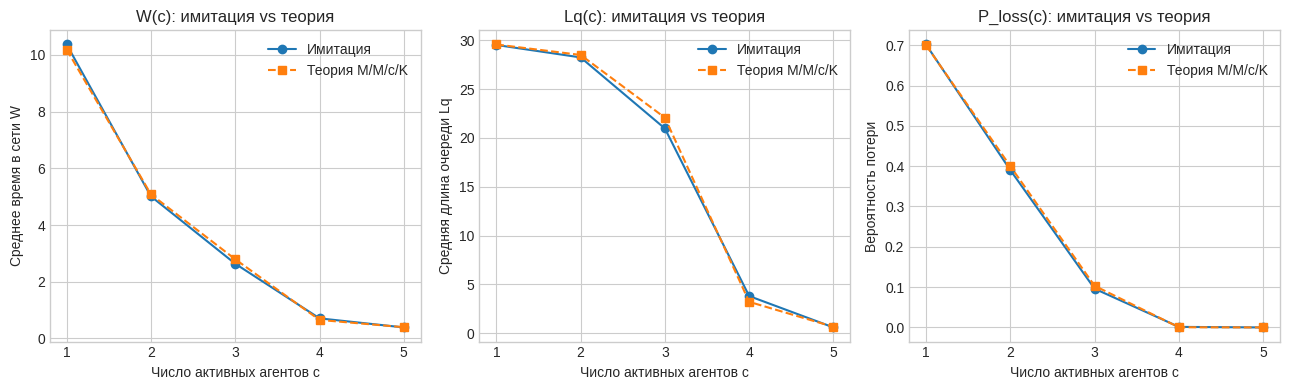

In [13]:
cs = [r['c'] for r in fixed_results]

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(cs, [r['W_sim'] for r in fixed_results], 'o-', label='Имитация')
plt.plot(cs, [r['W_theory'] for r in fixed_results], 's--', label='Теория M/M/c/K')
plt.xlabel('Число активных агентов c')
plt.ylabel('Среднее время в сети W')
plt.title('W(c): имитация vs теория')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(cs, [r['Lq_sim'] for r in fixed_results], 'o-', label='Имитация')
plt.plot(cs, [r['Lq_theory'] for r in fixed_results], 's--', label='Теория M/M/c/K')
plt.xlabel('Число активных агентов c')
plt.ylabel('Средняя длина очереди Lq')
plt.title('Lq(c): имитация vs теория')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(cs, [r['P_loss_sim'] for r in fixed_results], 'o-', label='Имитация')
plt.plot(cs, [r['P_loss_theory'] for r in fixed_results], 's--', label='Теория M/M/c/K')
plt.xlabel('Число активных агентов c')
plt.ylabel('Вероятность потери')
plt.title('P_loss(c): имитация vs теория')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
dynamic_metrics, dynamic_node = run_simulation(
    lam=LAMBDA,
    mu=MU,
    sim_time=SIM_TIME,
    min_agents=MIN_AGENTS,
    max_agents=MAX_AGENTS,
    initial_agents=INITIAL_ACTIVE_AGENTS,
    queue_capacity=QUEUE_CAPACITY,
    dynamic=True,
    alpha_on=ALPHA_ON,
    beta_off=BETA_OFF,
    seed=SEED,
    routing=ROUTING,
)

node_loads_df = pd.DataFrame(dynamic_metrics['node_loads'])

print('Сводные метрики сети:')
print({k: v for k, v in dynamic_metrics.items() if k != 'node_loads'})
print('\nЗагрузка по узлам:')
node_loads_df

Сводные метрики сети:
{'arrivals': 18640, 'completed': 9710, 'lost': 251, 'avg_system_time': np.float64(1.3966802423636935), 'avg_queue_len': 7.474166069746969, 'avg_active_agents': 12.409185306896507, 'loss_probability': 0.013465665236051503}

Загрузка по узлам:


,node_id,avg_busy_agents,avg_active_agents,util_active,util_max,avg_queue_len,arrivals,lost
0,0,3.590774,4.195311,0.855902,0.718155,7.163488,10971,251
1,1,1.449212,4.143748,0.349735,0.289842,0.185476,4390,0
2,2,1.115758,4.070126,0.274134,0.223152,0.125203,3279,0


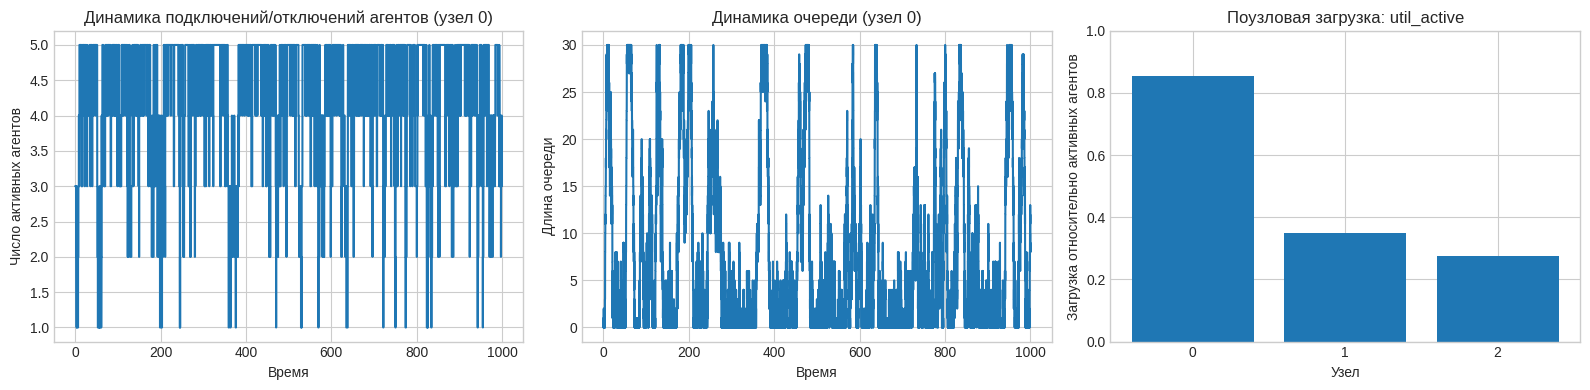

In [15]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.step(dynamic_node.agents_ts, dynamic_node.agents_vals, where='post')
plt.xlabel('Время')
plt.ylabel('Число активных агентов')
plt.title('Динамика подключений/отключений агентов (узел 0)')

plt.subplot(1, 3, 2)
plt.step(dynamic_node.ts, dynamic_node.qs, where='post')
plt.xlabel('Время')
plt.ylabel('Длина очереди')
plt.title('Динамика очереди (узел 0)')

plt.subplot(1, 3, 3)
node_ids = [d['node_id'] for d in dynamic_metrics['node_loads']]
util_active = [d['util_active'] for d in dynamic_metrics['node_loads']]
plt.bar(node_ids, util_active)
plt.ylim(0, 1)
plt.xticks(node_ids)
plt.xlabel('Узел')
plt.ylabel('Загрузка относительно активных агентов')
plt.title('Поузловая загрузка: util_active')

plt.tight_layout()
plt.show()

In [16]:
alpha_grid = [0.2, 0.5, 1.0, 1.5, 2.0]
beta_grid = [0.2, 0.5, 1.0]

sensitivity = []

for a in alpha_grid:
    for b in beta_grid:
        m, _ = run_simulation(
            lam=LAMBDA,
            mu=MU,
            sim_time=SIM_TIME,
            min_agents=MIN_AGENTS,
            max_agents=MAX_AGENTS,
            initial_agents=INITIAL_ACTIVE_AGENTS,
            queue_capacity=QUEUE_CAPACITY,
            dynamic=True,
            alpha_on=a,
            beta_off=b,
            seed=SEED + int(100*a + 10*b),
            routing=ROUTING,
        )
        sensitivity.append({
            'alpha_on': a,
            'beta_off': b,
            'W': m['avg_system_time'],
            'Lq': m['avg_queue_len'],
            'A': m['avg_active_agents'],
            'P_loss': m['loss_probability'],
        })

sensitivity[:5], len(sensitivity)

([{'alpha_on': 0.2,
   'beta_off': 0.2,
   'W': np.float64(3.0918592247362744),
   'Lq': 19.148772965948254,
   'A': 9.998186064481926,
   'P_loss': 0.14551839066777764},
  {'alpha_on': 0.2,
   'beta_off': 0.5,
   'W': np.float64(7.323891866445658),
   'Lq': 30.265260822072097,
   'A': 4.850432295857263,
   'P_loss': 0.40856430561665935},
  {'alpha_on': 0.2,
   'beta_off': 1.0,
   'W': np.float64(8.89861410454073),
   'Lq': 30.0897006844472,
   'A': 3.7398368131953537,
   'P_loss': 0.4924568123192371},
  {'alpha_on': 0.5,
   'beta_off': 0.2,
   'W': np.float64(1.0188318946778736),
   'Lq': 3.96770049960168,
   'A': 13.352487709410106,
   'P_loss': 0.00248953864081784},
  {'alpha_on': 0.5,
   'beta_off': 0.5,
   'W': np.float64(2.9727495636901202),
   'Lq': 19.82397926008115,
   'A': 9.222761649426664,
   'P_loss': 0.10597919286612553}],
 15)

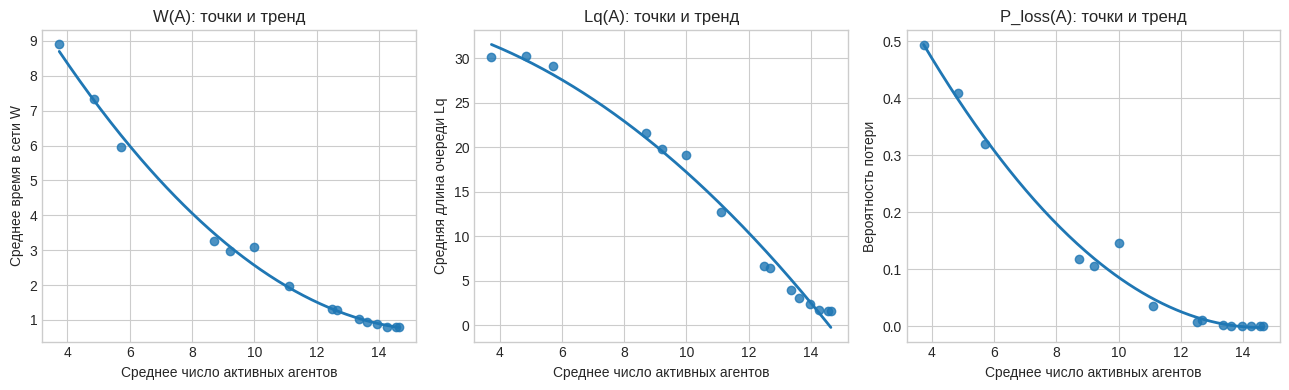

In [17]:
A = np.array([r['A'] for r in sensitivity])
W = np.array([r['W'] for r in sensitivity])
Lq = np.array([r['Lq'] for r in sensitivity])
Pl = np.array([r['P_loss'] for r in sensitivity])

x_line = np.linspace(A.min(), A.max(), 200)

w_coef = np.polyfit(A, W, deg=2)
lq_coef = np.polyfit(A, Lq, deg=2)
pl_coef = np.polyfit(A, Pl, deg=2)

W_line = np.polyval(w_coef, x_line)
Lq_line = np.polyval(lq_coef, x_line)
Pl_line = np.polyval(pl_coef, x_line)

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.scatter(A, W, alpha=0.8)
plt.plot(x_line, W_line, '-', linewidth=2)
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Среднее время в сети W')
plt.title('W(A): точки и тренд')

plt.subplot(1, 3, 2)
plt.scatter(A, Lq, alpha=0.8)
plt.plot(x_line, Lq_line, '-', linewidth=2)
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Средняя длина очереди Lq')
plt.title('Lq(A): точки и тренд')

plt.subplot(1, 3, 3)
plt.scatter(A, Pl, alpha=0.8)
plt.plot(x_line, Pl_line, '-', linewidth=2)
plt.xlabel('Среднее число активных агентов')
plt.ylabel('Вероятность потери')
plt.title('P_loss(A): точки и тренд')

plt.tight_layout()
plt.show()